# 主成分分析（PCA）学习

**目标**：搞懂 PCA 的本质

## 1. PCA 是什么？为什么要用？

### 核心思想（一句话记死）
**PCA 就是找到数据“最长、最粗的方向”（主成分），把数据投影到这些方向上，实现降维 + 去噪声 + 可视化**

### 经典应用场景
- 高维数据可视化（1000维 → 2维）
- 数据压缩（减少存储和计算）
- 去相关性（特征去冗余）
- 特征提取（人脸Eigenface、手写数字）

## 2. 数学原理（带公式推导）

### 2.1 数据中心化（必须第一步！）
$$
\tilde{X} = X - \mu \quad (\mu = \frac{1}{m}\sum x_i)
$$

### 2.2 协方差矩阵
$$
\Sigma = \frac{1}{m-1} \tilde{X}^T \tilde{X} \quad \text{(无偏估计)}
$$

### 2.3 特征值分解（核心！）
$$
\Sigma = V \Lambda V^T
$$
- V 的列 = 主成分方向（单位正交向量）
- Λ 对角线 = 每个方向的方差（解释能力）

### 2.4 降维投影
$$
Z = \tilde{X} V_k \quad \text{(k 个主成分)}
$$

### 2.5 方差解释比例
$$
\text{Explained Variance Ratio}_i = \frac{\lambda_i}{\sum \lambda_j}
$$

## 3. 纯 NumPy 手写 PCA

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_digits
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# 设置中文字体（可选）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

## 4. 手写 PCA 类

In [8]:
class MyPCA:
    def __init__(self, n_components):
        self.n_components = n_components
        self.components_ = None      # 主成分方向
        self.mean_ = None
        self.explained_variance_ = None
        self.explained_variance_ratio_ = None
    
    def fit(self, X):
        # 1. 中心化
        self.mean_ = np.mean(X, axis=0)
        X_centered = X - self.mean_
        
        # 2. 协方差矩阵（也可以用 np.cov(X_centered.T)）
        cov_matrix = np.cov(X_centered.T)  # (d, d)
        
        # 3. 特征值分解
        eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
        
        # 4. 按特征值大小排序
        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]
        
        # 5. 取前 k 个
        self.components_ = eigenvectors[:, :self.n_components]
        self.explained_variance_ = eigenvalues[:self.n_components]
        self.explained_variance_ratio_ = eigenvalues[:self.n_components] / eigenvalues.sum()
        
        return self
    
    def transform(self, X):
        X_centered = X - self.mean_
        return X_centered @ self.components_
    
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)
    
    def inverse_transform(self, Z):
        return Z @ self.components_.T + self.mean_

## 5. 案例1：Iris 数据集 4维 → 2维 可视化

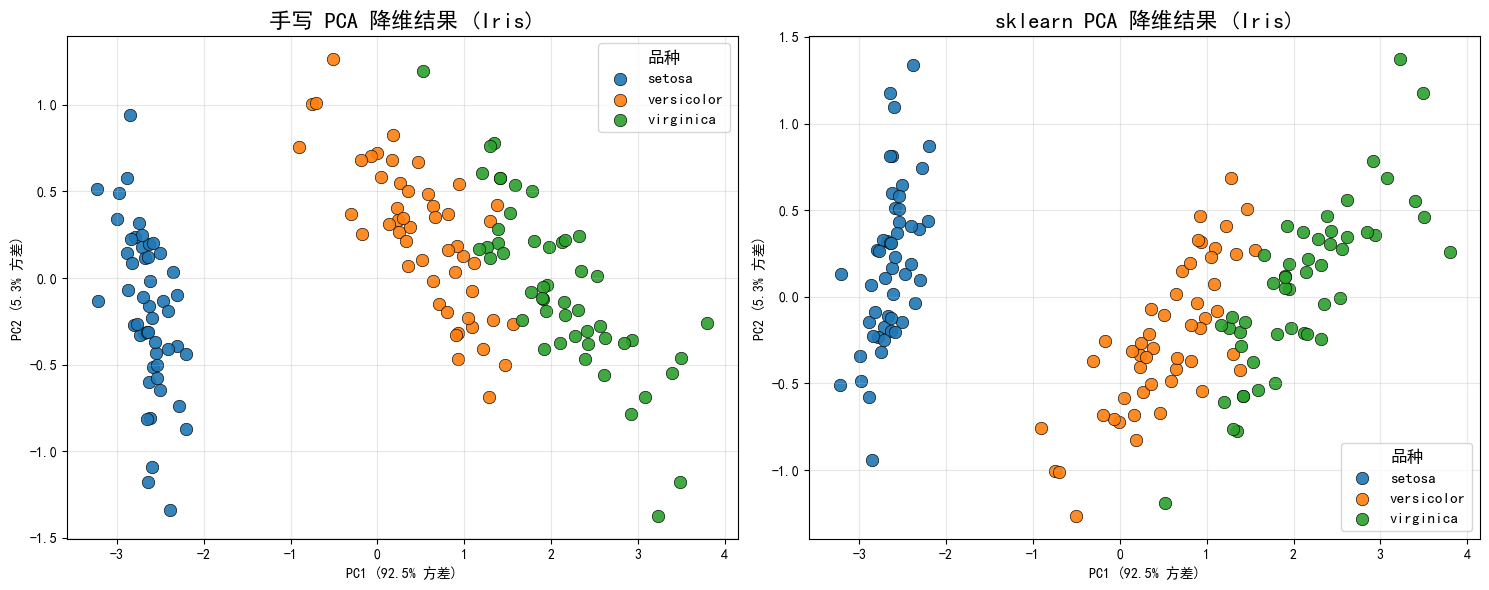

手写 PCA 前两个主成分解释方差比例: 97.77%
sklearn PCA 前两个主成分解释方差比例: 97.77%


In [15]:
# 加载数据
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
feature_names = iris.feature_names

# 手写 PCA
pca_my = MyPCA(n_components=2)
X_2d_my = pca_my.fit_transform(X_iris)

# sklearn 官方 PCA（对比）
from sklearn.decomposition import PCA
pca_sk = PCA(n_components=2)
X_2d_sk = pca_sk.fit_transform(X_iris)

# 可视化对比（修复 legend 问题）
plt.figure(figsize=(15, 6))

# 左图：手写 PCA
plt.subplot(1, 2, 1)
for i, name in enumerate(iris.target_names):
    plt.scatter(X_2d_my[y_iris == i, 0], 
                X_2d_my[y_iris == i, 1], 
                label=name, 
                s=80, edgecolor='k', linewidth=0.5, alpha=0.9)

plt.title('手写 PCA 降维结果 (Iris)', fontsize=16, weight='bold')
plt.xlabel(f'PC1 ({pca_my.explained_variance_ratio_[0]:.1%} 方差)')
plt.ylabel(f'PC2 ({pca_my.explained_variance_ratio_[1]:.1%} 方差)')
plt.legend(title='品种', fontsize=11, title_fontsize=12)
plt.grid(True, alpha=0.3)

# 右图：sklearn PCA
plt.subplot(1, 2, 2)
for i, name in enumerate(iris.target_names):
    plt.scatter(X_2d_sk[y_iris == i, 0], 
                X_2d_sk[y_iris == i, 1], 
                label=name, 
                s=80, edgecolor='k', linewidth=0.5, alpha=0.9)

plt.title('sklearn PCA 降维结果 (Iris)', fontsize=16, weight='bold')
plt.xlabel(f'PC1 ({pca_sk.explained_variance_ratio_[0]:.1%} 方差)')
plt.ylabel(f'PC2 ({pca_sk.explained_variance_ratio_[1]:.1%} 方差)')
plt.legend(title='品种', fontsize=11, title_fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"手写 PCA 前两个主成分解释方差比例: {pca_my.explained_variance_ratio_.sum():.2%}")
print(f"sklearn PCA 前两个主成分解释方差比例: {pca_sk.explained_variance_ratio_.sum():.2%}")

## 6. 方差解释率曲线

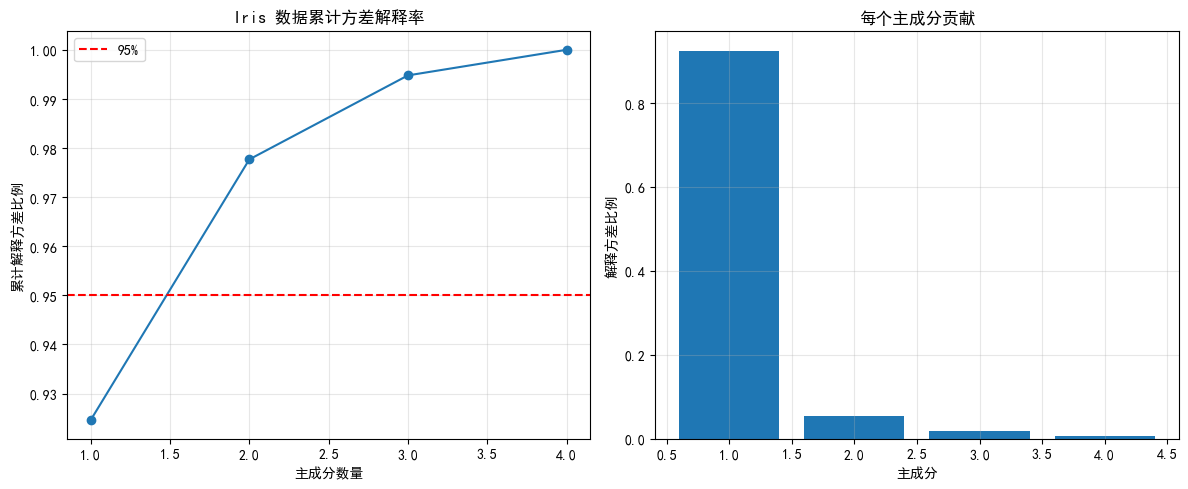

In [10]:
# 完整特征值分析
pca_full = MyPCA(n_components=X_iris.shape[1])
pca_full.fit(X_iris)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(pca_full.explained_variance_)+1), 
         np.cumsum(pca_full.explained_variance_ratio_), 'o-')
plt.xlabel('主成分数量')
plt.ylabel('累计解释方差比例')
plt.title('Iris 数据累计方差解释率')
plt.grid(True, alpha=0.3)
plt.axhline(0.95, color='red', linestyle='--', label='95%')
plt.legend()

plt.subplot(1, 2, 2)
plt.bar(range(1, len(pca_full.explained_variance_)+1), pca_full.explained_variance_ratio_)
plt.xlabel('主成分')
plt.ylabel('解释方差比例')
plt.title('每个主成分贡献')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**结论**：Iris 数据用 2 个主成分就能解释 97.8% 的方差！完美降维！

## 7. 重建误差（信息损失了多少）

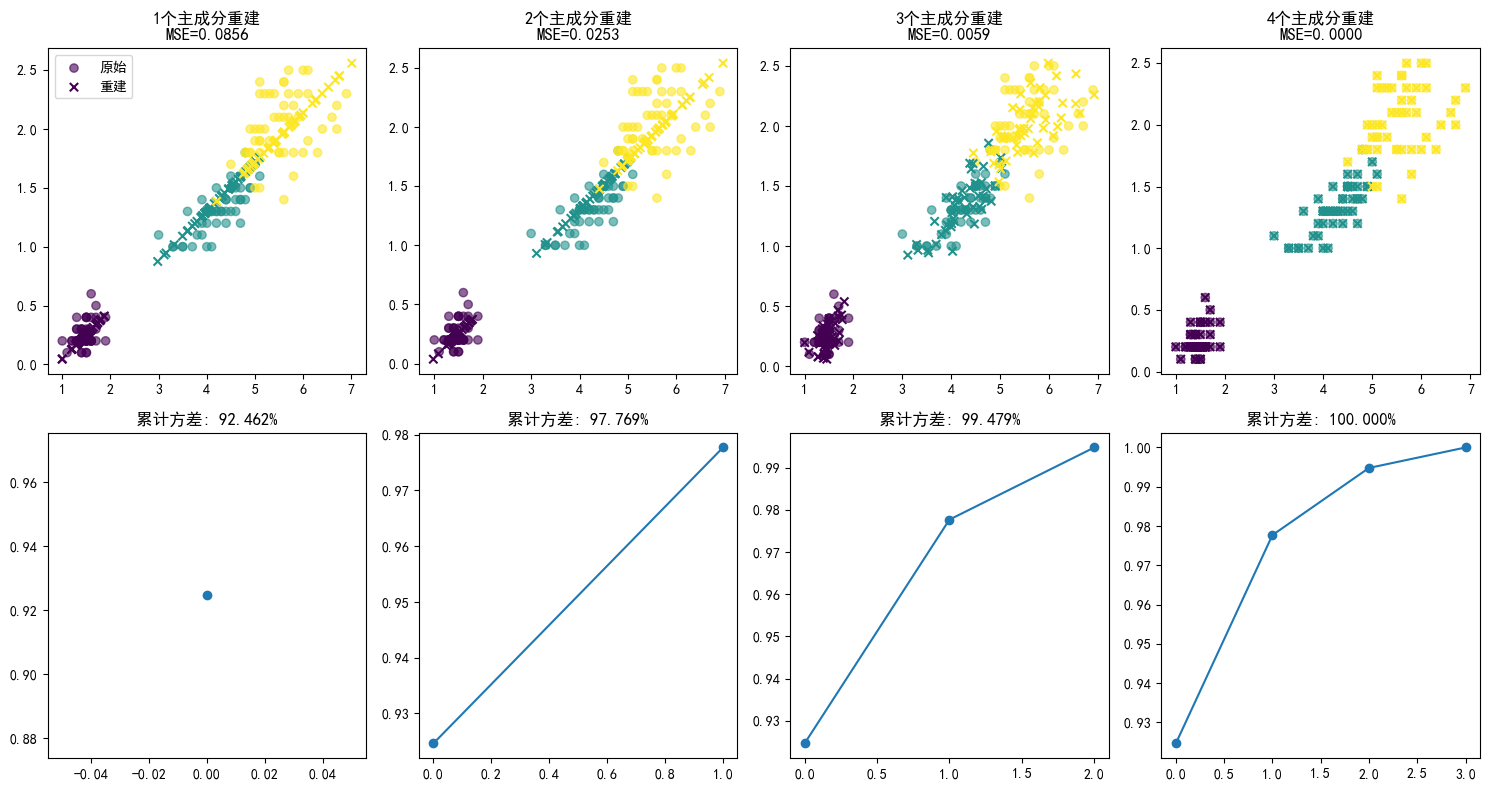

In [12]:
# 不同维度重建对比
components_list = [1, 2, 3, 4]
plt.figure(figsize=(15, 8))

for i, n in enumerate(components_list, 1):
    pca = MyPCA(n_components=n)
    X_reduced = pca.fit_transform(X_iris)
    X_reconstructed = pca.inverse_transform(X_reduced)
    
    error = np.mean((X_iris - X_reconstructed)**2)
    
    plt.subplot(2, 4, i)
    plt.scatter(X_iris[:, 2], X_iris[:, 3], c=y_iris, alpha=0.6, label='原始')
    plt.scatter(X_reconstructed[:, 2], X_reconstructed[:, 3], c=y_iris, marker='x', label='重建')
    plt.title(f'{n}个主成分重建\nMSE={error:.4f}')
    if i == 1: plt.legend()

    plt.subplot(2, 4, i+4)
    plt.plot(range(len(pca.explained_variance_ratio_)), np.cumsum(pca.explained_variance_ratio_), 'o-')
    plt.title(f'累计方差: {np.cumsum(pca.explained_variance_ratio_)[-1]:.3%}')

plt.tight_layout()
plt.show()

## 8. 终极挑战：手写数字 MNIST 784维 → 2维 可视化

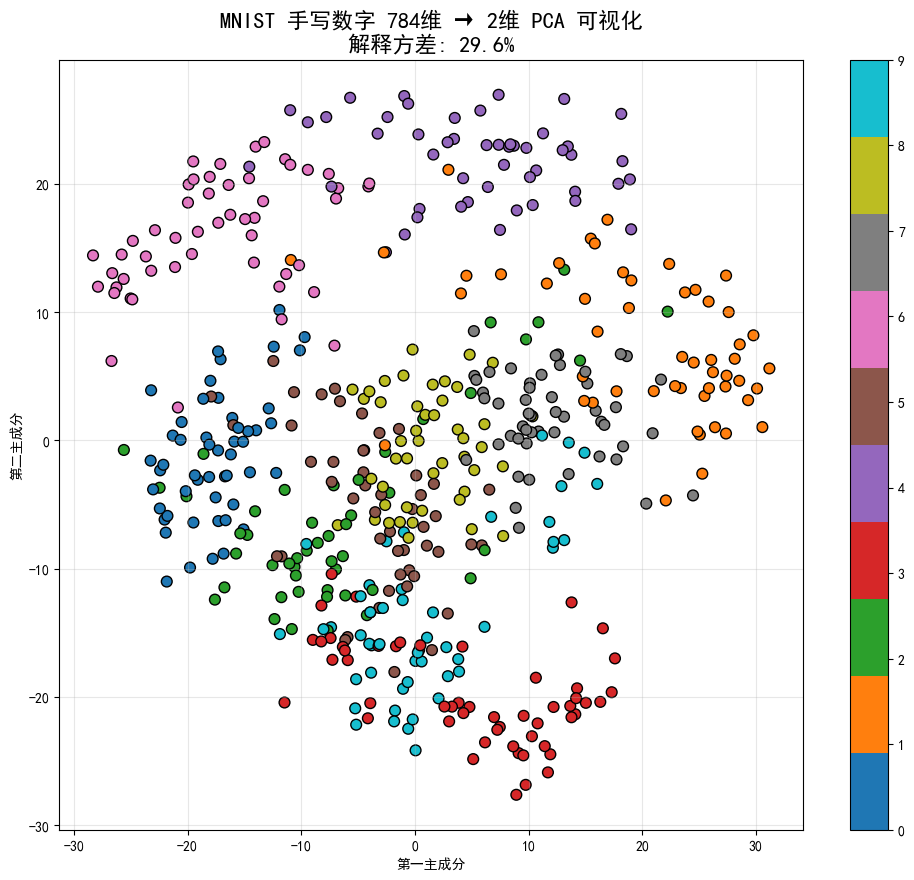

即使只用2个主成分，也能看出数字0-9的聚类结构！


In [13]:
# 加载手写数字（小样本）
digits = load_digits()
X_digits = digits.data[:500]   # 取前500个加快速度
y_digits = digits.target[:500]

# PCA 降到 2 维
pca_digits = MyPCA(n_components=2)
X_2d_digits = pca_digits.fit_transform(X_digits)

plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_2d_digits[:, 0], X_2d_digits[:, 1], 
                     c=y_digits, cmap='tab10', edgecolor='k', s=60)
plt.colorbar(scatter, ticks=range(10))
plt.title('MNIST 手写数字 784维 → 2维 PCA 可视化\n'
          f'解释方差: {pca_digits.explained_variance_ratio_.sum():.1%}', 
          fontsize=16, weight='bold')
plt.xlabel('第一主成分')
plt.ylabel('第二主成分')
plt.grid(True, alpha=0.3)
plt.show()

print("即使只用2个主成分，也能看出数字0-9的聚类结构！")